In [1]:
import numpy as np
import numpy.linalg as la # Доступ к линейной алгебре
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D # расширение matplotlib для 3D‑графиков
from matplotlib import cm # цветовые палитры для заливки графиков
from sklearn import datasets
from sklearn.preprocessing import StandardScaler #  для стандартизации признаков
from sklearn.metrics import mean_squared_error # метрика MSE
from pandas.plotting import table # позволяет добавлять таблички (например, результаты метрик, параметры) прямо на графики matplotlib

%matplotlib inline
%matplotlib widget
plt.rcParams["figure.figsize"] = [12,8] # устанавливает размер всех будущих графиков (12×8 дюймов)

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Линейная регрессия

In [3]:
# создаёт массив размера 100×1 со случайными числами из равномерного распределения на отрезке, *2 растягивает диапозон [0,2)
x = 2 * np.random.rand(100,1) 
y = 4 + 3 * x + np.random.randn(100,1) # истинная модель: y≈4+3x наклон - 3, сдвиг - 4
# np.random.randn(100,1) добавляет нормальный шум (среднее 0, дисперсия 1) к каждому значению.
df = pd.DataFrame(np.hstack([x,y]), columns=['x','y'])
# np.hstack([x,y]) объединяет столбцы x и y в один массив 100×2, создаёт таблицу pandas с двумя столбцами: x (признак) и y (целевая переменная)
df.head()

,x,y
0,0.152509,4.612127
1,1.386033,8.826827
2,1.883268,8.572468
3,0.901665,6.247321
4,0.955438,5.995819


Text(0, 0.5, 'y (target)')

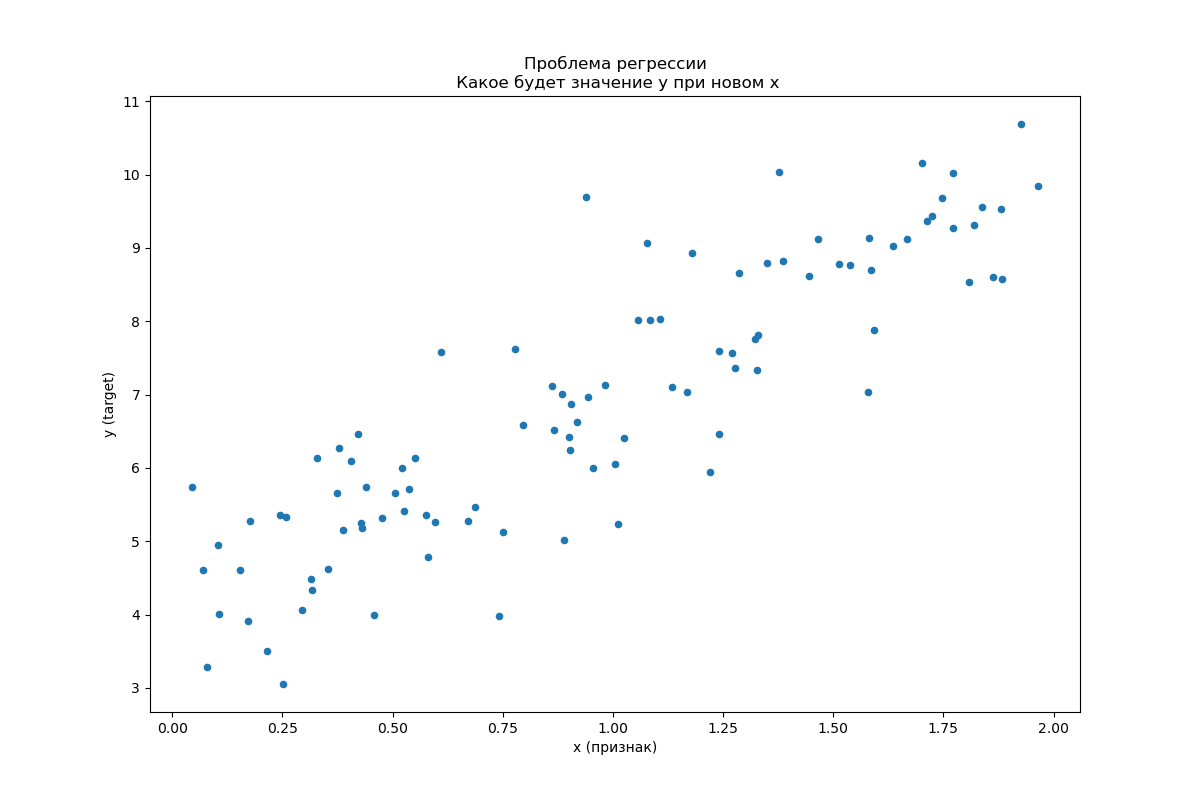

In [4]:
df.plot.scatter('x', 'y')
plt.title("Проблема регрессии\n Какое будет значение y при новом x")
plt.xlabel("x (признак)")
plt.ylabel("y (target)")

# Парная регрессия 
### Описание данных
$$
y = \beta_0 + \beta_1 x + \varepsilon
$$

### Предсказание
$$
\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x
$$

Построим случайную прямую. Насколько хорошо она описывает данные?

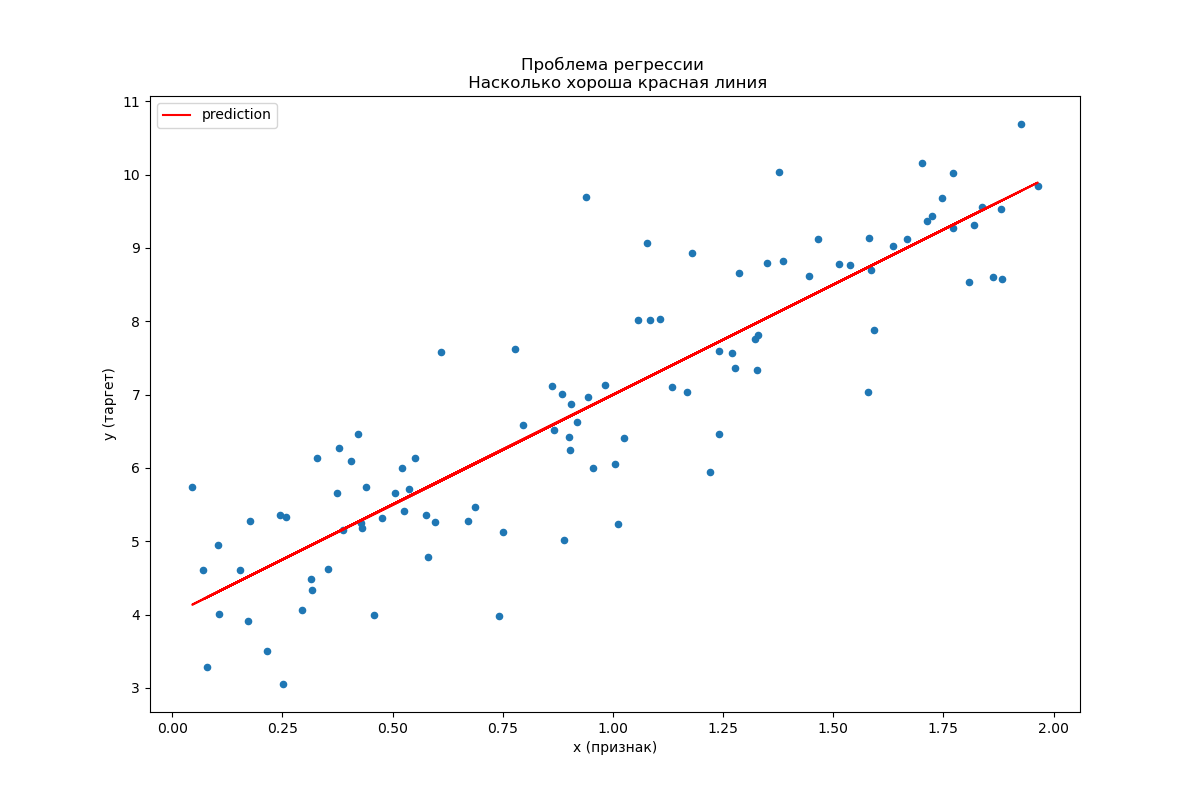

In [5]:
def predict(x):
    return 3 * x + 4

df.plot.scatter('x', 'y')
plt.title("Проблема регрессии \n Насколько хороша красная линия")
plt.xlabel("x (признак)")
plt.ylabel("y (таргет)")
plt.plot(x, predict(x), color='red', label='prediction')
plt.legend()
# plt.savefig('pics/regression_random_line.pdf')

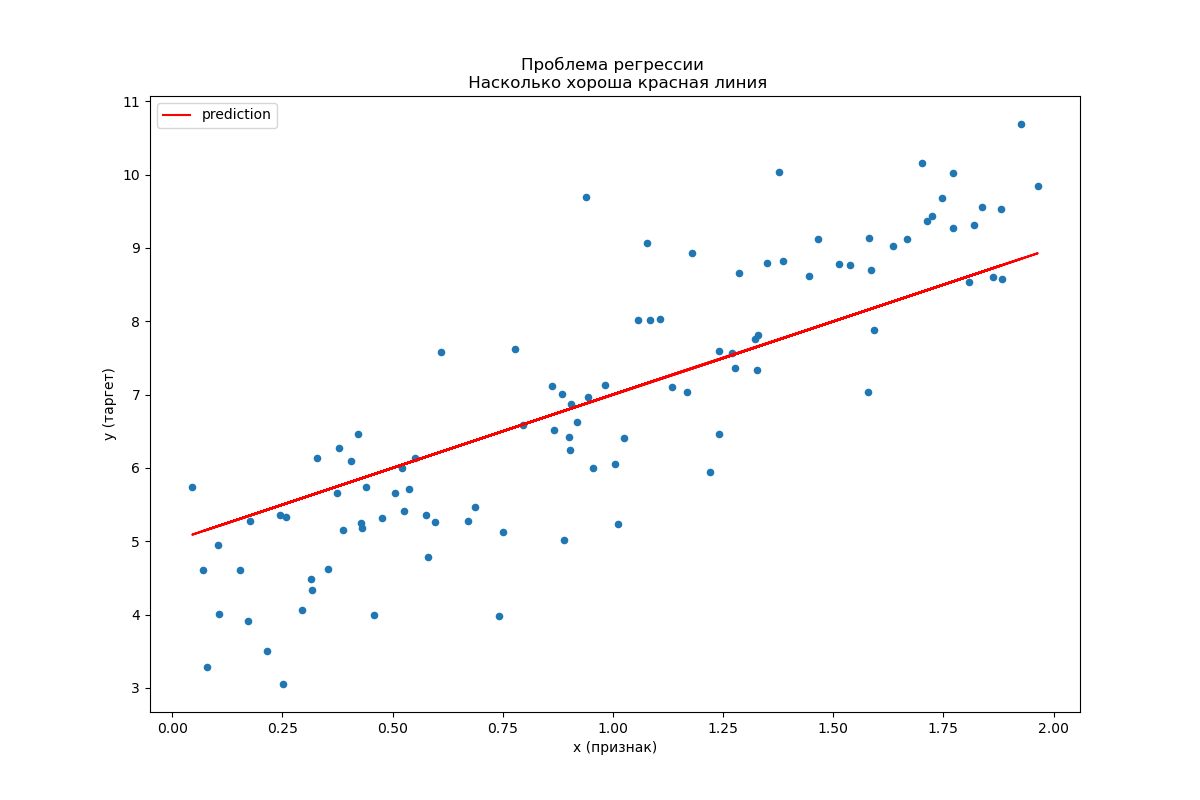

In [6]:
def predict(x):
    return 2 * x + 5

df.plot.scatter('x', 'y')
plt.title("Проблема регрессии \n Насколько хороша красная линия")
plt.xlabel("x (признак)")
plt.ylabel("y (таргет)")
plt.plot(x, predict(x), color='red', label='prediction')
plt.legend()
# plt.savefig('pics/regression_random_line.pdf')

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_1 = 2 * x + 5
y_pred_2 = 3 * x + 4

def print_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"Метрики для модели: {model_name}")
    print(f"MAE : {mae:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}\n")

print_metrics(y, y_pred_1, "Линия 2x + 5")
print_metrics(y, y_pred_2, "Линия 3x + 4")

Метрики для модели: Линия 2x + 5
MAE : 0.8295
MSE : 1.0778
RMSE: 1.0381
R2: 0.6905

Метрики для модели: Линия 3x + 4
MAE : 0.6792
MSE : 0.7792
RMSE: 0.8827
R2: 0.7762



### RSS

Residual Sum of Squares (Сумма квадратов остатков)

$$RSS = \mathcal{L}(y, \hat{y}) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \to \min$$

Метод наименьших квадратов. Эта метрика была выбрана как функция, которую легко было минимизировать. После было доказано (теорема Гаусса Маркова), что она дает оптимальное решение (при определенных условиях, накладываемых на данные).


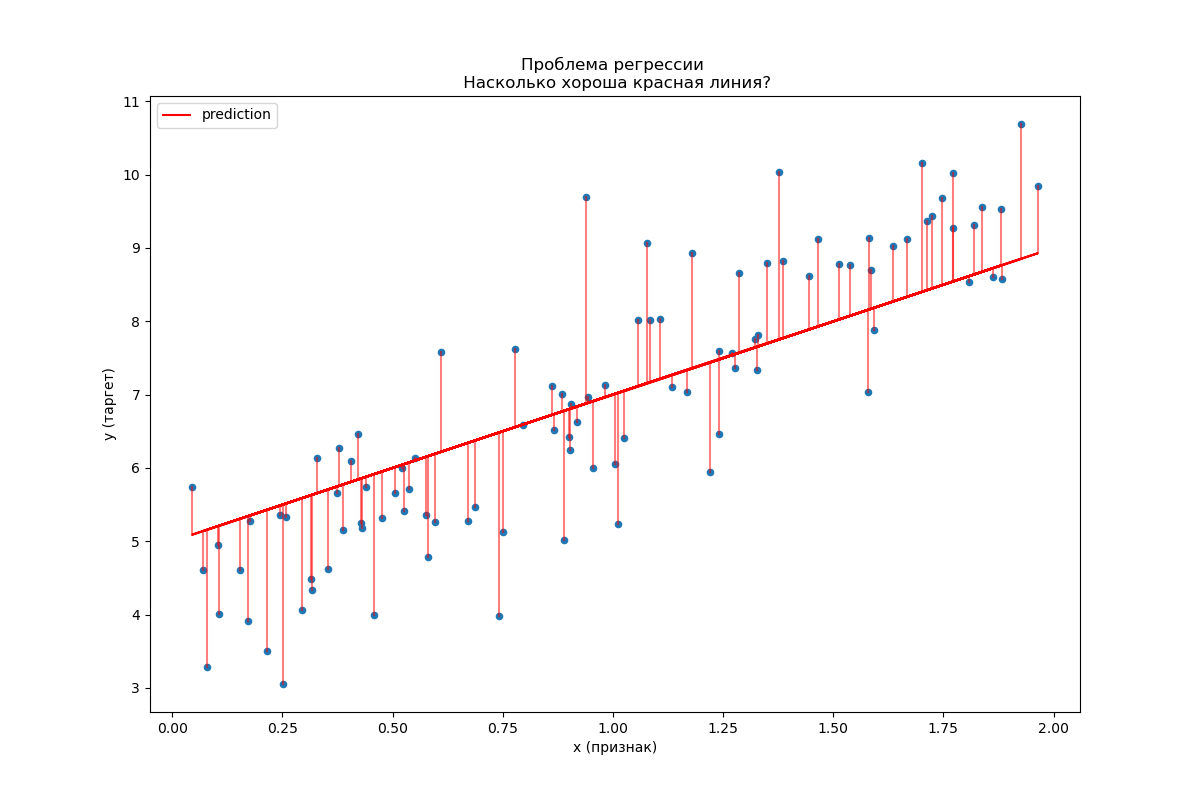

In [8]:
y_pred = predict(x) # predict(x) возвращает для каждого x[i] значение 2x_i + 5

df.plot.scatter('x', 'y')
plt.title("Проблема регрессии \n Насколько хороша красная линия?")
plt.xlabel("x (признак)")
plt.ylabel("y (таргет)")
plt.plot(x, y_pred, color='red', label='prediction')
plt.legend()

for x_i, y_i, y_i_pred in zip(x, y, y_pred):
    plt.plot([x_i, x_i], [y_i_pred, y_i], color='red', alpha=0.5)

In [9]:
rss = ((y - y_pred) ** 2).sum()
# y - y_pred — это вектор остатков (разницы между истинным y и предсказанием y_pred)
# (y - y_pred) ** 2 — вектор квадратов этих остатков
# .sum() суммирует все квадраты ошибок по объектам:
print(rss)

print(mean_squared_error(y, y_pred) * y.size)
# mean_squared_error(y, y_pred) считает средний квадрат ошибки, y.size - общее число элементов (n)

107.77514114158588
107.77514114158589


### Минимизация - $\beta_0$

$$RSS = \mathcal{L}(y, \hat{y}) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \to \min$$

$$\frac{d\mathcal{L}}{d\beta_0} = \frac{d}{d\beta_0} \left( \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \right) = \frac{d}{d\beta_0} \left( \sum_{i=1}^{n} (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i)^2 \right) = -2 \sum_{i=1}^{n} (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i) = 0$$

$$-\sum_{i=1}^{n} y_i + \sum_{i=1}^{n} \hat{\beta}_0 + \sum_{i=1}^{n} \hat{\beta}_1 x_i = 0$$

$$n\hat{\beta}_0 = \sum_{i=1}^{n} y_i - \sum_{i=1}^{n} \hat{\beta}_1 x_i$$

$$\hat{\beta}_0 = \frac{\sum_{i=1}^{n} y_i}{n} - \frac{\sum_{i=1}^{n} \hat{\beta}_1 x_i}{n}$$

### Замечание

$$\bar{y} = \frac{\sum_{i=1}^{n} y_i}{n}$$

$$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

### Поэтому

$$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

### Минимизация - $\beta_1$

$$RSS = \mathcal{L}(y, \hat{y}) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \to \min$$

$$\frac{d\mathcal{L}}{d\beta_1} = \frac{d}{d\beta_1} \left( \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \right) = \frac{d}{d\beta_1} \left( \sum_{i=1}^{n} (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i)^2 \right) = -2 \sum_{i=1}^{n} x_i (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i) = 0$$

### Подставим $\beta_0$

$$-2 \sum_{i=1}^{n} x_i (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i) = 0$$

$$\sum_{i=1}^{n} (x_i y_i - x_i \bar{y} + x_i \hat{\beta}_1 \bar{x} - x_i \hat{\beta}_1 x_i) = 0$$

$$\sum_{i=1}^{n} ((x_i y_i - x_i \bar{y}) + \hat{\beta}_1 (x_i \bar{x} - x_i^2)) = 0$$

$$\sum_{i=1}^{n} (x_i y_i - x_i \bar{y}) + \sum_{i=1}^{n} \hat{\beta}_1 (x_i \bar{x} - x_i^2) = 0$$

$$\hat{\beta}_1 \sum_{i=1}^{n} (x_i^2 - x_i \bar{x}) = \sum_{i=1}^{n} (x_i y_i - x_i \bar{y})$$

$$\hat{\beta}_1 = \frac{\sum_{i=1}^{n} (x_i y_i - x_i \bar{y})}{\sum_{i=1}^{n} (x_i^2 - x_i \bar{x})} = \frac{\sum_{i=1}^{n} x_i y_i - \sum_{i=1}^{n} x_i \bar{y}}{\sum_{i=1}^{n} x_i^2 - \sum_{i=1}^{n} x_i \bar{x}}$$

### Замечания

$$n\bar{x}\bar{y} = \sum_{i=1}^{n} x_i \bar{y} = \sum_{i=1}^{n} y_i \bar{x} = \sum_{i=1}^{n} \bar{y} x_i$$

$$\sum_{i=1}^{n} x_i \bar{x} = \frac{n\bar{x} \sum_{i=1}^{n} x_i}{n} = n\bar{x}^2$$

$$\sum_{i=1}^{n} x_i y_i - \sum_{i=1}^{n} x_i \bar{y} + n\bar{x}\bar{y} - n\bar{x}\bar{y} = \sum_{i=1}^{n} x_i y_i - \sum_{i=1}^{n} x_i \bar{y} + \sum_{i=1}^{n} \bar{x}\bar{y} - \sum_{i=1}^{n} \bar{x} y_i = \sum_{i=1}^{n} (x_i y_i - x_i \bar{y} + \bar{x}\bar{y} - \bar{x} y_i) = \sum_{i=1}^{n} ((x_i - \bar{x})(y_i - \bar{y}))$$

### Знаменатель

$$\sum_{i=1}^{n} x_i^2 - \sum_{i=1}^{n} x_i \bar{x} = \sum_{i=1}^{n} (x_i^2 - x_i \bar{x}) = \sum_{i=1}^{n} (x_i^2 - x_i \bar{x} - x_i \bar{x} + \bar{x}\bar{x}) = \sum_{i=1}^{n} (x_i^2 - 2x_i \bar{x} + \bar{x}\bar{x}) = \sum_{i=1}^{n} (x_i^2 - 2x_i \bar{x} + \bar{x}^2) = \sum_{i=1}^{n} (x_i - \bar{x})^2$$

### В итоге

$$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

$$\hat{\beta}_1 = \frac{\sum_{i=1}^{n} ((x_i - \bar{x})(y_i - \bar{y}))}{\sum_{i=1}^{n} (x_i - \bar{x})^2}$$



In [10]:
def estimate(x, y):
    y_av = y.mean() # средние по выборке
    x_av = x.mean() # средние по выборке

    b1 = ((x - x_av) * (y - y_av)).sum() / ((x - x_av) ** 2).sum() 
    #Числитель ((x - x_av) * (y - y_av)).sum() это выборочная ковариация cov(x,y)
    # Знаменатель ((x - x_av) ** 2).sum() — это сумма квадратов отклонений ∑(x_i − x)^ 2
    # В итоге b1 — это оценка углового коэффициента парной регрессии
    
    b0 = y_av - b1 * x_av # b0 — свободный член

    return b0, b1

def predict_estimated(x0, b0, b1): # Это линейное предсказание по обученным коэффициентам b0, b1
    # x0 — новое значение (или массив) признака x
    return b0 + x0 * b1

In [72]:
y_pred = predict_estimated(x, b0, b1)

n = len(y)

mae = np.abs(y - y_pred).mean()
mse = ((y - y_pred) ** 2).mean()
rmse = np.sqrt(mse)

ss_res = ((y - y_pred) ** 2).sum()
ss_tot = ((y - y.mean()) ** 2).sum()
r2 = 1 - (ss_res / ss_tot)

print("Метрики качества модели:")
print(f"MAE:  {mae:.4f} - модель ошибается на это кол-во единиц")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

Метрики качества модели:
MAE:  0.7736 - модель ошибается на это кол-во единиц
MSE:  0.9186
RMSE: 0.9584
R²:   0.8044


In [11]:
b0, b1 = estimate(x, y) # обучает парную линейную регрессию по методу наименьших квадратов (МНК) на твоих данных x и y

In [12]:
b0, b1

(np.float64(4.0106836714690015), np.float64(2.9911194403315364))

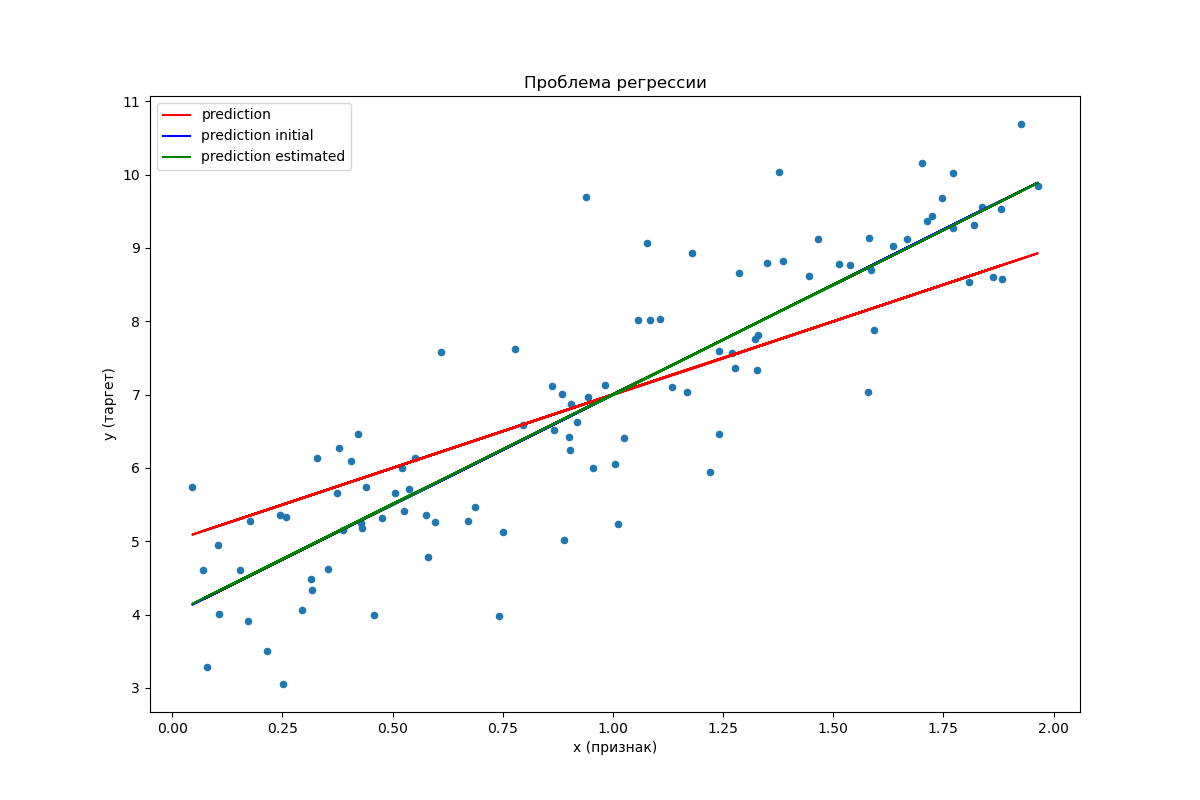

In [13]:
df.plot.scatter('x', 'y')
plt.title("Проблема регрессии")
plt.xlabel("x (признак)")
plt.ylabel("y (таргет)")
plt.plot(x, predict(x), color='red', label='prediction')
plt.plot(x, predict_estimated(x, 4, 3), color='blue', label='prediction initial')
plt.plot(x, predict_estimated(x, b0, b1), color='green', label='prediction estimated')
plt.legend()
# plt.savefig('pics/regression_estimated.pdf')

# синяя линия - идеальное предсказание
# зеленая линия - оцененное значение которое мы провели, после минимизации отклонения
# красная линия - произвольная

In [14]:
print("estimated values: b0= {}, b1= {}".format(b0, b1))
print("initial values: b0 = 4, b1 = 3")

estimated values: b0= 4.0106836714690015, b1= 2.9911194403315364
initial values: b0 = 4, b1 = 3


In [15]:
# Еще один вариант оценки линейной модели, но через функцию np.linalg.lstsq — по‑существу, это тот же МНК, только в матричной форме.
x_dummy = np.hstack([x, np.ones(x.shape[0]).reshape(-1,1)])
# x — это массив признака размера (100, 1)
# np.ones(x.shape[0]).reshape(-1,1) — столбец единиц той же длины, что и x || np.hstack([...]) «склеивает» их по столбцам
m,c = np.linalg.lstsq(x_dummy, y)[0]
# m — наклон (аналог b1 в твоём estimate) || c — свободный чл|ен (аналог b0)
print(m, c)

[2.99111944] [4.01068367]


# Множественная регрессия

**Предсказание**

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_p x_p$$


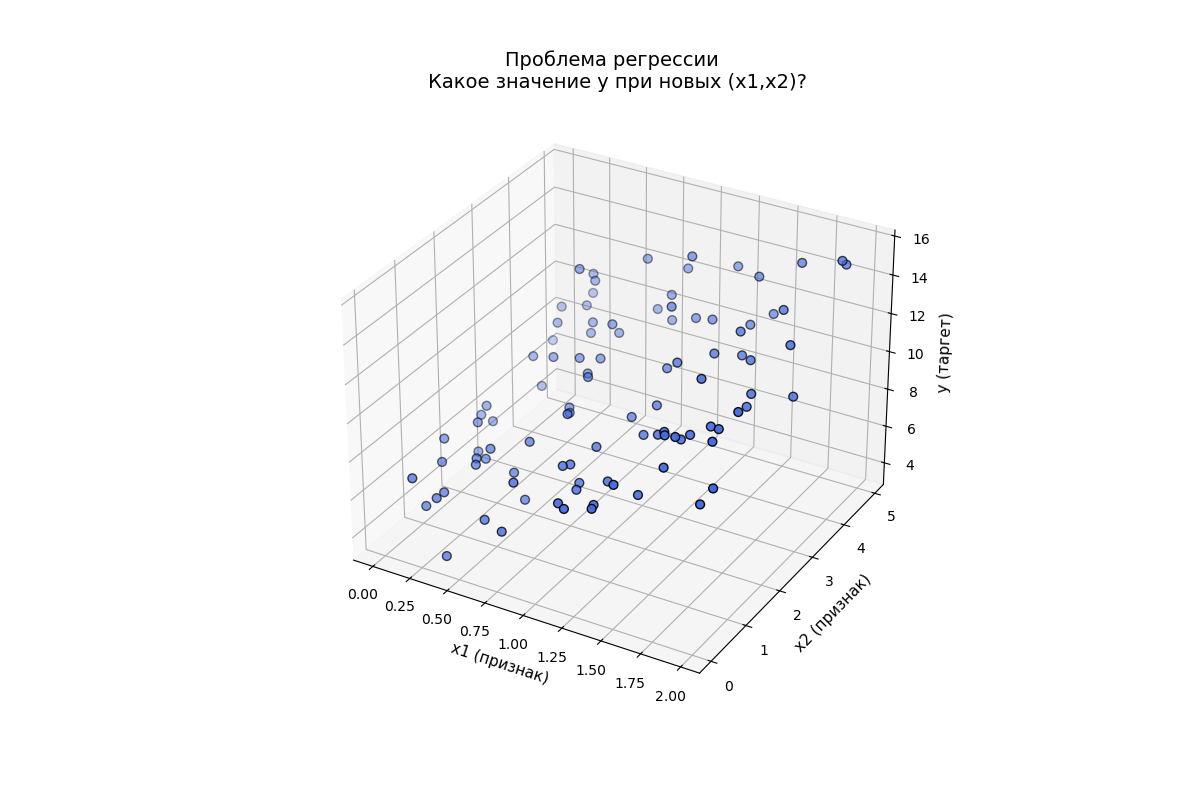

In [16]:
plt.rcParams["figure.figsize"] = [12, 8]
fig = plt.figure()
ax = fig.add_subplot(projection='3d') 

np.random.seed(42) 
x1 = 2 * np.random.rand(100, 1)
x2 = 5 * np.random.rand(100, 1)
y = 4 + 3 * x1 + x2 + np.random.randn(100, 1)

ax.scatter(x1, x2, y, marker='o', color='royalblue', s=40, edgecolors='k')

ax.set_title("Проблема регрессии \n Какое значение y при новых (x1,x2)?", fontsize=14)
ax.set_xlabel("x1 (признак)", fontsize=11)
ax.set_ylabel("x2 (признак)", fontsize=11)
ax.set_zlabel("y (таргет)", fontsize=11)

plt.show()

### Матричная форма 

Введем $x_0$ - вектор единиц:

$$X = \begin{bmatrix} 1 & x_{11} & \dots & x_{p1} \\ 1 & x_{12} & \dots & x_{p2} \\ \dots & \dots & \dots & \dots \\ 1 & x_{n1} & \dots & x_{nl} \end{bmatrix} \quad \theta = \begin{bmatrix} \theta_0 \\ \theta_1 \\ \dots \\ \theta_p \end{bmatrix} \quad y = \begin{bmatrix} y_1 \\ y_2 \\ \dots \\ y_n \end{bmatrix}$$

$$X\theta = y$$

$$x_{n \cdot p} \cdot \theta_{p \cdot 1} = y_{n \cdot 1}$$

$$RSS = \mathcal{L}(y, \hat{y}) = \sum_{i=1}^{n} (y_i - x_i^T \theta)^2 =$$

$$= (y_1 - x_1^T \theta)^2 + (y_2 - x_2^T \theta)^2 + \dots + (y_n - x_n^T \theta)^2 =$$

$$= [y_1 - x_1^T \theta, y_2 - x_2^T \theta, \dots, y_n - x_n^T \theta] \begin{bmatrix} y_1 - x_1^T \theta \\ y_2 - x_2^T \theta \\ \dots \\ y_n - x_n^T \theta \end{bmatrix} =$$

$$= (y - X\theta)^T (y - X\theta)$$


#### Производная в матрице

Здесь под производной скалярной функции $f(x)$ по вектору $x$ понимается градиент
$$\frac{df(x)}{dx} = \left[ \frac{df(x)}{dx_1}, \dots, \frac{df(x)}{dx_d} \right]^T$$

Свойства, которые понадобятся далее:
$$\frac{dx^T A}{dx} = \frac{d A^T x}{dx} = A$$

$$\frac{dx^T Ax}{dx} = 2Ax$$

Приравниваем производную к нулю

$$\frac{d\mathcal{L}}{d\theta} = \frac{d}{d\theta}(y - X\theta)^T (y - X\theta) =$$

$$= \frac{d}{d\theta}(y^T - (X\theta)^T)(y - X\theta) =$$

$$= \frac{d}{d\theta}((y^T - (X\theta)^T)y - (y^T - (X\theta)^T)(X\theta)) =$$

$$= \frac{d}{d\theta}(y^Ty - (X\theta)^Ty - y^TX\theta + (X\theta)^TX\theta) =$$

$$= \frac{d}{d\theta}(y^Ty - \theta^TX^Ty - y^TX\theta + \theta^TX^TX\theta) =$$

$$= \frac{d}{d\theta}(y^Ty) - \frac{d}{d\theta}(\theta^T(X^Ty)) - \frac{d}{d\theta}((y^TX)\theta) + \frac{d}{d\theta}(\theta^T(X^TX)\theta) =$$

$$= 0 - X^Ty - X^Ty + 2X^TX\theta = -2X^Ty + 2X^TX\theta = 0$$


$$X^T X \theta = X^T y$$

$$(X^T X)^{-1} X^T X \theta = (X^T X)^{-1} X^T y$$

$$\theta = (X^T X)^{-1} X^T y$$


In [17]:
# Реализация многомерной линейной регрессии в явном виде

x = np.hstack([np.ones(x1.shape[0]).reshape(-1, 1), x1, x2]) 
# np.ones(...).reshape(-1, 1) — столбец единиц, длины 100 || np.hstack([...]) делает матрицу 100×3

w = la.inv(x.T.dot(x)).dot(x.T).dot(y)
#x.T.dot(x) — матрица X^T * X размера 3x3
# la.inv(...) — обратная к ней матрица
# x.T.dot(y) — вектор X^T * y размера 3x1

print(w)

# Это точное решение задачи МНК для линейной модели
# w будет вектором 3×1
# [[w0],
#  [w1],
#  [w2]]

# где:
# w0 ≈ 4,
# w1 ≈ 3,
# w2 ≈ 1,

[[3.91061004]
 [2.82913734]
 [1.14386228]]


In [18]:
# x — это матрица признаков размера n×p (в твоём случае n×3 — свободный член + x1 + x2)
# w — вектор коэффициентов размера p×1 (в твоём случае 3×1)
def predict_estimated(x, w): 
    return x.dot(w) # dot — это метод у NumPy‑массива, который делает матричное умножение
    # x.dot(w) — это вектор предсказанных y

def plane(x1,x2): # Это идеальная модель, по которой ты генерировал y
    return 4 + x1 * 3 + x2

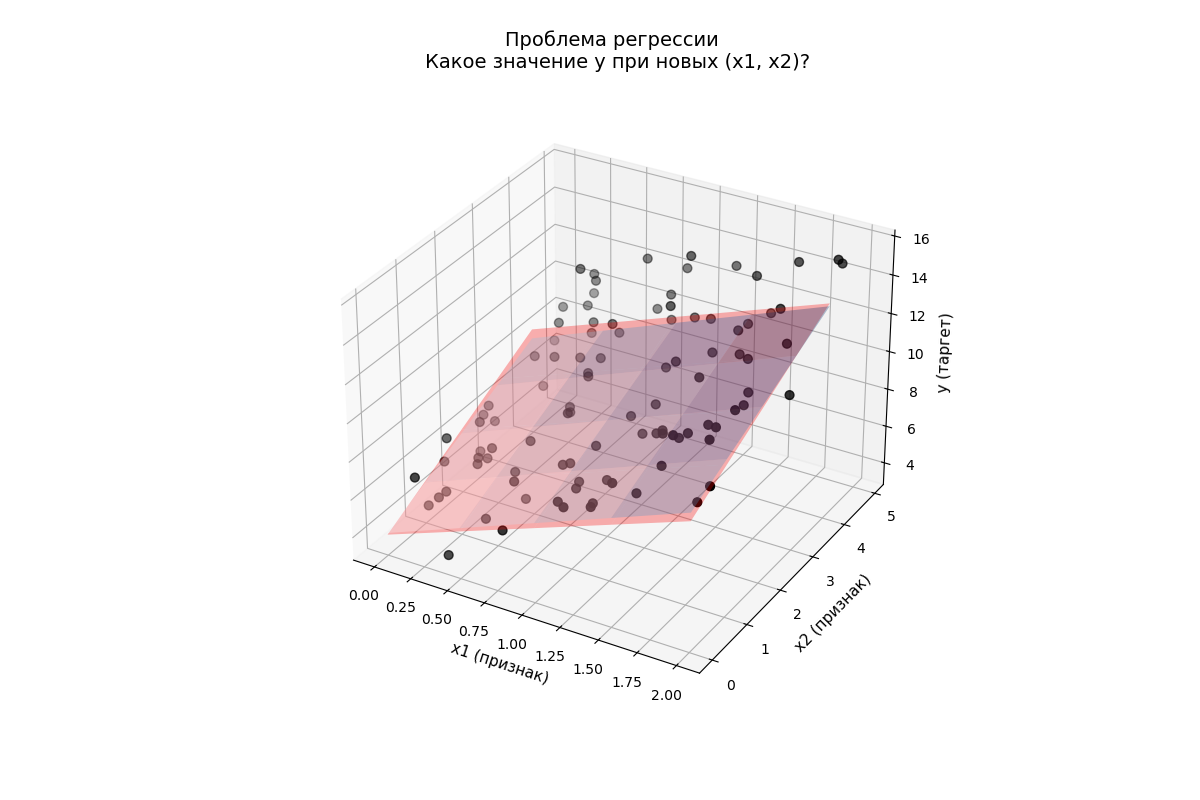

In [19]:
fig = plt.figure(figsize=(12, 8)) # 20x10 обычно слишком много для экрана ноутбука
ax = fig.add_subplot(projection='3d') 

# Сетка для отрисовки плоскостей
x1_surfs = np.arange(0, 2.5, 0.5)
x2_surfs = np.arange(0, 5.0, 1)
x1_surf, x2_surf = np.meshgrid(x1_surfs, x2_surfs) # строит двумерную сетку по x1_surfs/x2_surfs
# где каждая пара (x1_surf[i,j], x2_surf[i,j]) — это точка на плоскости, по которой ты будешь вычислять y


zs = np.array([plane(x, y) for x, y in zip(x1_surf.ravel(), x2_surf.ravel())])
# x1_surf.ravel(), x2_surf.ravel() — превращают 2D‑массивы в плоские 1D‑массивы («всё подряд»): это удобно, потому что zip требует итерируемых объектов той же длины
# [plane(x, y) for x, y in zip(...)] — генератор‑список: для каждой пары (x,y) из сетки вызывает plane(x,y) = 4 + 3x + y и собирает значения z для каждой точки
# np.array(...) — превращает список в NumPy‑массив zs (1D), затем z = zs.reshape(x1_surf.shape) — разворачивает его обратно в 2D‑массив, соответствующий сетк
z = zs.reshape(x1_surf.shape)
# reshape(...) — NumPy‑метод, который перестраивает плоский массив zs обратно в 2D‑форму, 
# соответствующую x1_surf и x2_surf (для plot_surface он нужен именно в таком виде)
ax.plot_surface(x1_surf, x2_surf, z, alpha=0.3, cmap='Blues', label='True Plane')
# ax.plot_surface(...) — 3D‑метод matplotlib, рисующий поверхность по трём 2D‑массивам

zs_pred = np.array([predict_estimated(np.array([[1, x, y]]), w) for x, y in zip(x1_surf.ravel(), x2_surf.ravel())])
# x1_surf.ravel(), x2_surf.ravel() — снова превращают сетку в плоский набор точек
# np.array([[1, x, y]]) — создаёт одну строку признаков вида [1, x1, x2] для конкретной точки (x,y) (в форме 1×3)
# predict_estimated(..., w) — это x.dot(w); для этой строки 1×3 он возвращает одно число — предсказание y для этой точки
# np.array(...) собирает все такие предсказания в 1D‑массив zs_pred
z_predicted = zs_pred.reshape(x1_surf.shape)
# reshape снова превращает 1D‑массив zs_pred в 2D‑массив той же формы, что x1_surf, чтобы подойти под plot_surface
ax.plot_surface(x1_surf, x2_surf, z_predicted, alpha=0.3, color='red', label='Predicted Plane')
# ax.plot_surface(...) — снова рисует 3D‑поверхность, но уже по предсказанным значениям z_predicted


ax.scatter(x1.ravel(), x2.ravel(), y.ravel(), color='black', marker='o', s=40, depthshade=True)
# x1.ravel(), x2.ravel(), y.ravel() — превращают столбцы 100×1 в 1D‑массивы 100 элементов, чтобы передать x, y, z для 3D‑scatter’а.

# Настройка подписей и оформления
ax.set_title("Проблема регрессии \n Какое значение y при новых (x1, x2)?", fontsize=14, pad=20)
ax.set_xlabel("x1 (признак)", fontsize=11)
ax.set_ylabel("x2 (признак)", fontsize=11)
ax.set_zlabel("y (таргет)", fontsize=11)

# plt.savefig("pics/regression_3d_estimated.pdf", bbox_inches='tight')

plt.show()

In [20]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression() # LinearRegression() — создаёт объект модели линейной регрессии; 
# это не функция, а класс‑объект, который потом обучается и предсказывает
lin_reg.fit(np.hstack([x1, x2]), y) 
# склеивает столбцы x1 и x2 в один матричный объект 100×2
# метод обучает модель на данных X и y по МНК
print("Intercept: {:.4f} \nSlopes: {}\n".format(lin_reg.intercept_[0], lin_reg.coef_[0]))
# lin_reg.intercept_ — это свободный член модели b0 (вектор‑столбец; intercept_[0] — скаляр)
# lin_reg.coef_ — это коэффициенты при признаках: coef_[0] — массив вида [coef_x1, coef_x2]
y_pred = lin_reg.predict(np.hstack([x1, x2]))
# lin_reg.predict(X) — метод возвращает предсказания y для всех объектов в X
print("Predictions\n", np.hstack([y_pred, y])[:10])
print("\nMSE: {:.4f}".format(mean_squared_error(y_pred, y)))

Intercept: 3.9106 
Slopes: [2.82913734 1.14386228]

Predictions
 [[ 6.20961421  5.72436192]
 [12.92984205 13.11859159]
 [ 9.85033257 10.25681603]
 [10.20665834  9.42045294]
 [ 9.98406165 11.33971872]
 [ 6.21904977  6.65626119]
 [ 6.5863708   5.20911279]
 [13.13290484 13.63136618]
 [ 8.62045185  7.77599923]
 [ 8.35735125  9.42041962]]

MSE: 0.9457


### Вычислительная сложность

Вычисляется матрица $(x^T x)^{-1}$ размера $p \times p$, где $p$ - количество признаков (feature). Вычислительная сложность обратной матрицы обычно от $O(p^{2.4})$ до $O(p^3)$ *(примечание: на слайде опечатка в символе $n$)*.

При удвоении количества признаков время на вычисления нужно умножить на от $2^{2.4} \approx 5.3$ до $2^3 = 8$.

Рассчет становится очень медленным, когда количество признаков очень большое - например, 100,000.

При этом рассчет линеен по отношению к количеству элементов выборки ($O(n)$). Т.о. можно эффективно обрабатывать большие наборы данных, если они помещаются в оперативную память.

При этом предсказание очень быстрое и зависит только от количества объектов, по которым необходимо рассчитать значение.



# Полиноминальная регрессия

#### Вопрос

Можно ли обобщить линейную регрессию на нелинейный случай?

In [21]:
m = 100
X = 6 * np.random.rand(m, 1) - 3 
# np.random.rand(m, 1) — создаёт массив 100×1 со случайными числами из равномерного распределения на интервале [0,1)
# 6 * ... — растягивает их на интервал [0, 6)
# - 3 — сдвигает интервал: теперь X примерно в [−3,3)
# То есть X — это случайные значения x на участке около [−3,3]
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)
# Это квадратичная модель со шумом:
# X**2 — возведение в квадрат поэлементно: для каждого X[i] берётся X[i] ** 2.
# 0.5 * X**2 — вклад квадратичного члена,
# X — линейный член,
# 2 — свободный член.

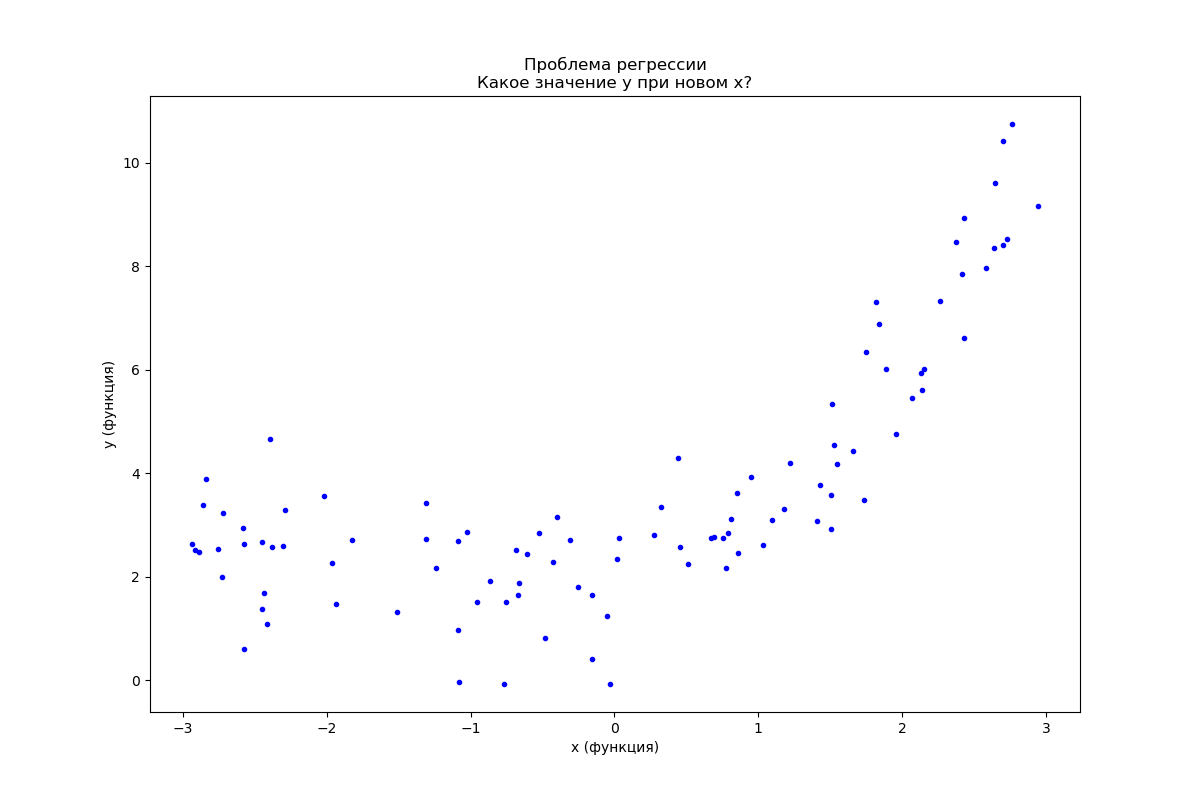

In [37]:
plt.clf()
plt.plot(X, y, "b.") # b. - сокращение b - color=blue, y - маркер в виде маленькой точки
plt.title("Проблема регрессии\nКакое значение y при новом x?")
plt.xlabel("x (функция)")
plt.ylabel("y (функция)")
#plt.savefig("pics/regression_poly.pdf")
plt.show()

Расширим пространство гипотез до всех полиномов степени $p$.

$$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_p x_p + \theta_{12} x_1^2 + \theta_{22} x_1 x_2 + \dots + \theta_{p2} x_1 x_p + \dots + \theta_{pp} x_p^2 + \dots
$$


In [29]:
from sklearn.preprocessing import PolynomialFeatures # класс для создания полиноминальных признаков
poly_features = PolynomialFeatures(degree=2, include_bias=False) # создает трансформер со степенью 2 и без свободного члена
X_poly = poly_features.fit_transform(X) # обучается на X и преобразует его в полиноминальные признаки

In [30]:
X[0]

array([2.72919168])

In [31]:
X_poly[0]

array([2.72919168, 7.44848725])

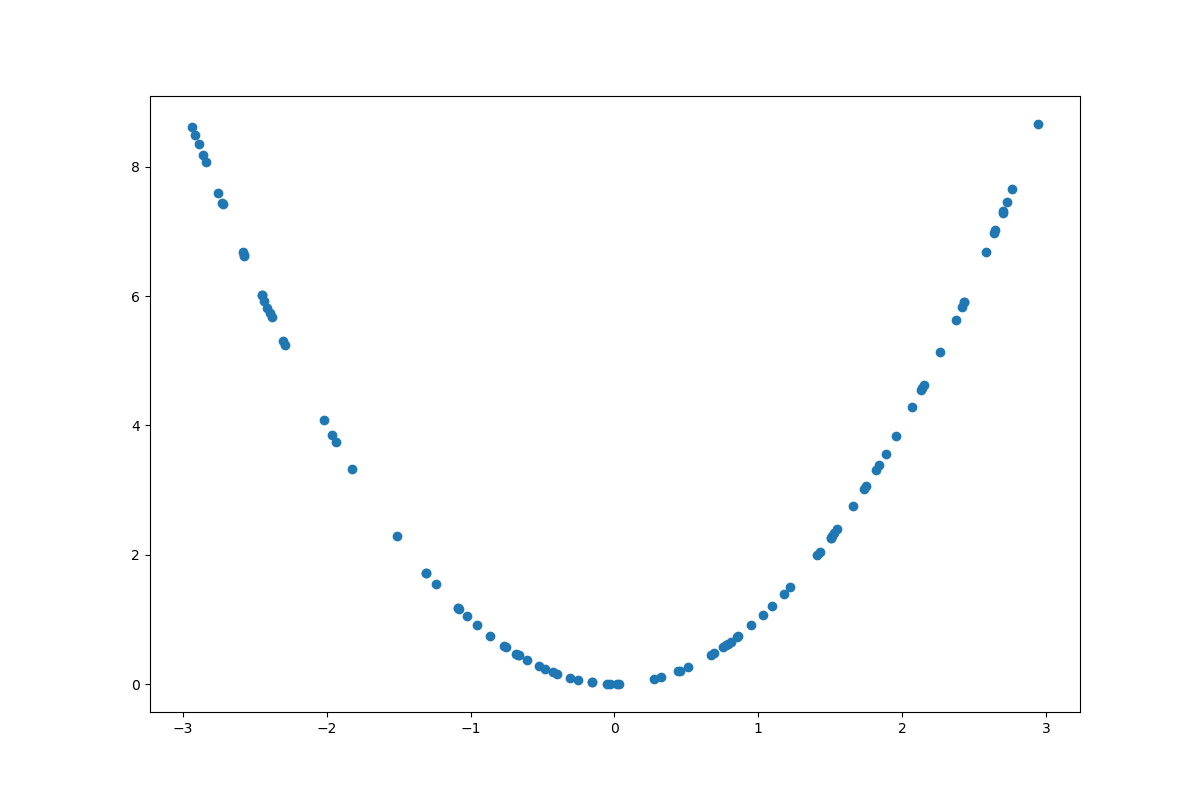

In [43]:
plt.figure()
plt.scatter(X_poly[:, 0], X_poly[:, 1]);
plt.show()

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_1^2$$

In [55]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_[0][0]

(array([2.01873554]), np.float64(1.0427153070767907))

Text(0, 0.5, 'y (функция)')

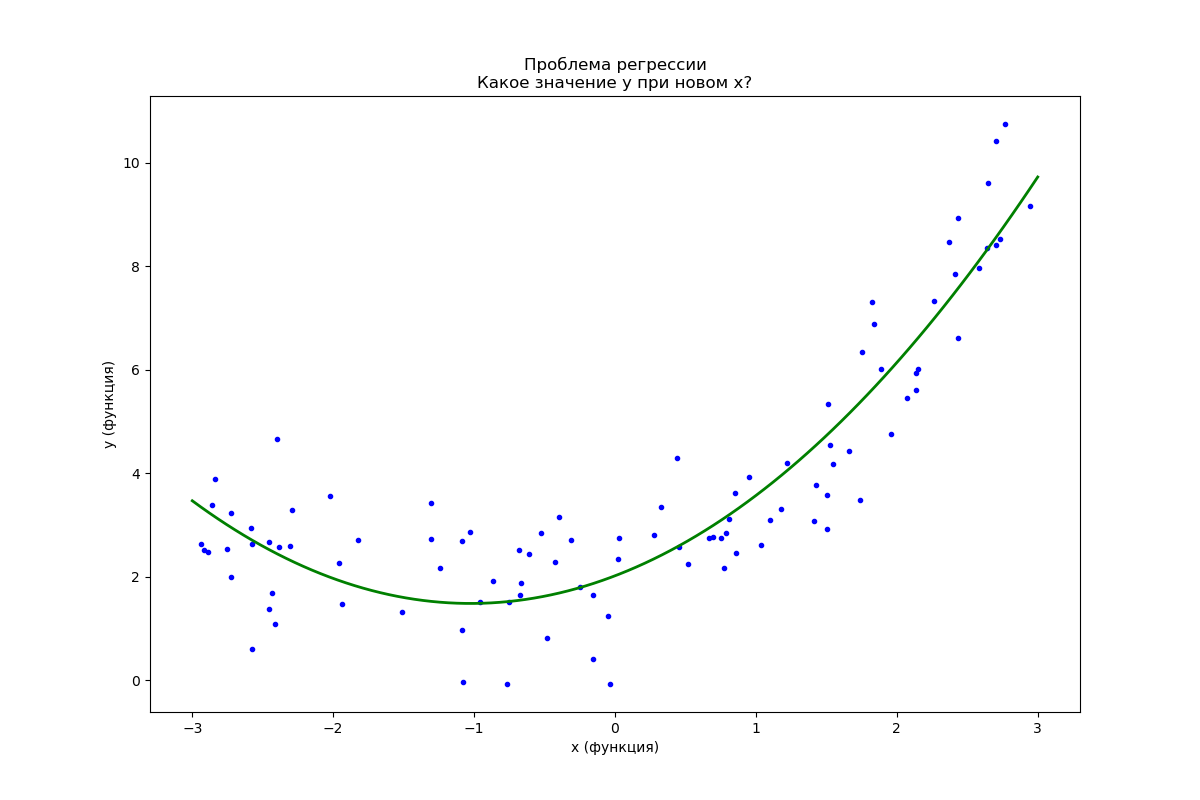

In [45]:
X_new = np.linspace(-3,3,100).reshape(100, 1)
#np.linspace(-3,3,100) - создает 100 равномерно распределенных значений от -3 до 3
#.reshape(100,1) - превращает 1D массив в 2D
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)
plt.figure()
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "g-", linewidth=2, label="Predictions")
plt.title("Проблема регрессии\nКакое значение y при новом x?")
plt.xlabel("x (функция)")
plt.ylabel("y (функция)")

# Проблема переобучения

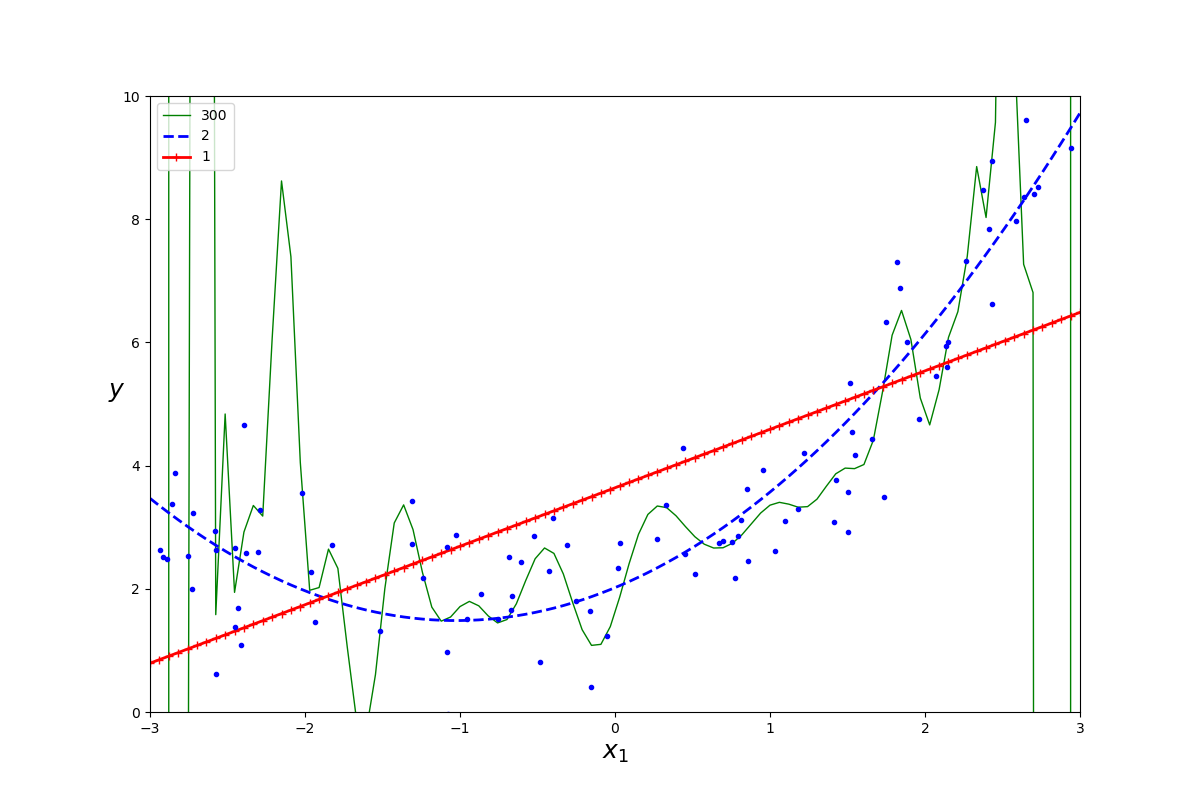

In [48]:
from sklearn.preprocessing import StandardScaler # класс для масштабирования
from sklearn.pipeline import Pipeline # класс для конвейера

plt.figure()

for style, width, degree in (("g-", 1, 300), ("b--", 2, 2), ("r-+", 2, 1)): # цвета и стили линии
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False) # Создаёт трансформер для генерации полиномиальных признаков
    std_scaler = StandardScaler() # Создаёт объект для масштабирования данных
    lin_reg = LinearRegression() # модель линейной регрессии

    # Создание конвейера из 3 шагов
    polynomial_regression = Pipeline([
        ("poly_features", polybig_features),
        ("std_scaler", std_scaler),
        ("lin_reg", lin_reg),
    ])

    polynomial_regression.fit(X, y) # Обучает модель: проходит по шагам Pipeline, на каждом шаге делает fit()
    y_newbig = polynomial_regression.predict(X_new)
    # Pipeline автоматически:
    # Применяет poly_features.transform(X_new) (полиномиальные признаки)
    # Применяет std_scaler.transform() (масштабирование)
    # Вызывает lin_reg.predict() (предсказание)
    
    plt.plot(X_new, y_newbig, style, label=str(degree), linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3,3,0,10])
plt.show()

### Упражнение

Предположим, мы получили несколько одинаковых по качеству моделей линейной регрессии. Какую из этих моделей стоит выбрать?

## Регуляризация

$$RSS = \mathcal{L}(y, \theta, x) = \sum_{i=1}^{n} (y_i - x_i^T \theta)^2 + \alpha R(\theta) \rightarrow min$$

### Гребневая регрессия (Ridge regression, регуляризация Тихонова, $L^2$-регуляризация)

$$RSS = \mathcal{L}(y, \theta, x) = \sum_{i=1}^{n} (y_i - x_i^T \theta)^2 + \alpha \sum_{i=1}^{n} \theta_i^2 \rightarrow min$$

#### Замечание
$\theta_0$ не участвует в регрессии, так как нужна возможность провести гиперплоскость с любым сдвигом.

Снова будем использовать свойство

$$\frac{d x^T A x}{d x} = 2Ax$$

$$\frac{d \mathcal{L}}{d \theta} = \frac{d}{d \theta} (y - X\theta)^T (y - X\theta) + \frac{d}{d \theta} \alpha \theta^T \theta =$$
$$= -2X^T y + 2X^T X \theta + 2\alpha \theta = 0$$

$$X^T X \theta + \alpha \theta = X^T y$$
$$(X^T X + \alpha E)\theta = X^T y$$

$E$ — единичная диагональная матрица

$$(X^T X + \alpha E)^{-1}(X^T X + \alpha E)\theta = (X^T X + \alpha E)^{-1} X^T y$$
$$\theta = (X^T X + \alpha E)^{-1} X^T y$$


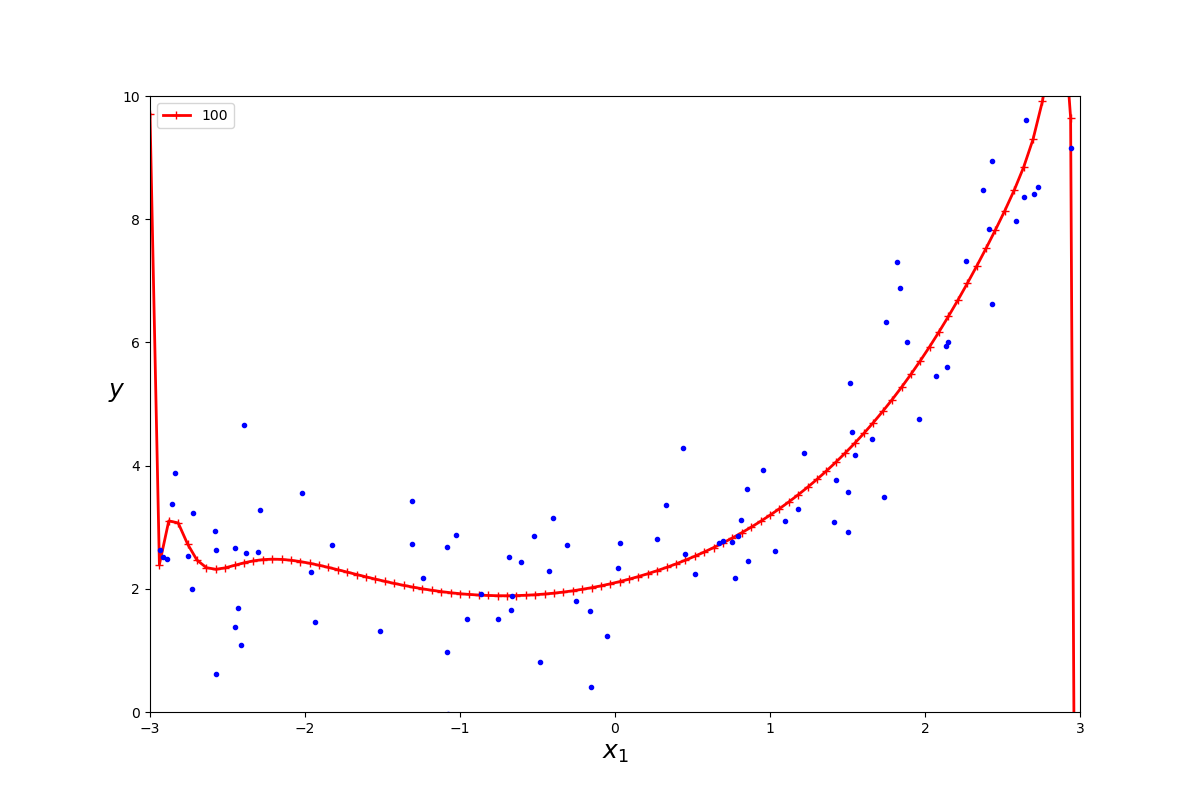

In [50]:
from sklearn.linear_model import Ridge # алгос решающий проблему линейной регресии с регуляризацией L^2 
polybig_features = PolynomialFeatures(degree=100, include_bias=False)

std_scaler = StandardScaler()

ridge_reg = Ridge(alpha=1) # линейная регрессия с L2-регуляризацией, alpha=1 — коэффициент, умножающий штраф за большие веса


polynomial_regression = Pipeline([
    ("poly_features", polybig_features),
    ("std_scaler", std_scaler),
    ("ridge_reg", ridge_reg),
])

polynomial_regression.fit(X, y)
y_newbig = polynomial_regression.predict(X_new)
plt.figure()
plt.plot(X_new, y_newbig, style, label=str(100), linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3,3,0,10])
plt.show()

In [53]:
ridge_reg.coef_[0]

np.float64(1.0655385903163277)

### Замечание

Гребнем является диагональная матрица, которую мы прибавляем к матрице $X^T X$ с линейнозависимыми колонками, в результате получаемая матрица не сингулярна (не имеет линейно зависимых строк и столбцов).


### Лассо регрессия (Least Absolute Shrinkage and Selection Operator Regression, Lasso regression, $L^1$-регуляризация)

$$RSS = \mathcal{L}(y, \theta, x) = \sum_{i=1}^{n}(y_i - x_i^T \theta)^2 + \alpha \sum_{i=1}^{n} |\theta_i| \rightarrow min$$

Сумма модулей весов

#### Замечание

$$|x|' = \frac{x}{|x|} = sign(x)$$

$$\frac{d\mathcal{L}}{d\theta_i} = 2 \sum_{i=1}^{n}((y_i - x_i^T \theta)x_i) + \alpha sign(\theta_i)$$

Такая задача не имеет решения в явном виде, для ее решения будем использовать градиентный спуск. Важно делать нормализацию признаков.


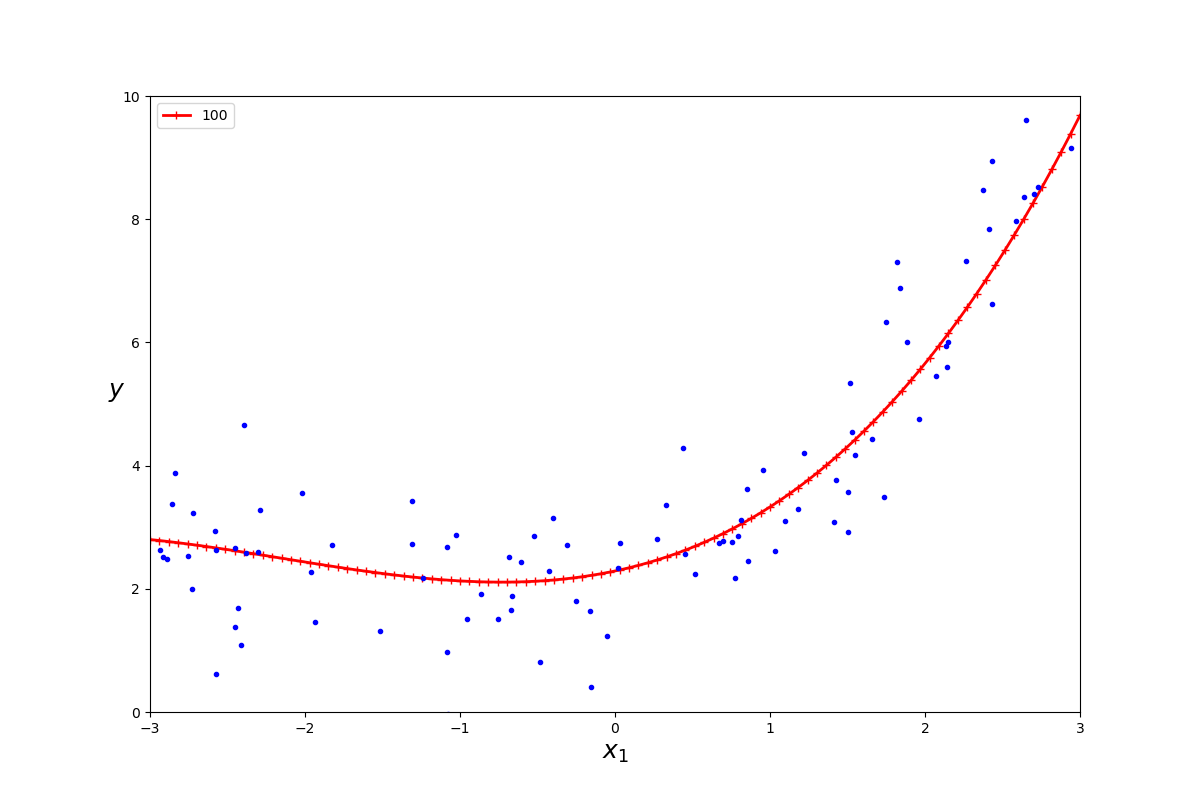

In [56]:
from sklearn.linear_model import Lasso

polybig_features = PolynomialFeatures(degree=100, include_bias=False)

std_scaler = StandardScaler()

lasso_reg = Lasso(alpha=0.2) # alpha - коэфициент регуляризации

polynomial_regression = Pipeline([
    ("poly_features", polybig_features),
    ("std_scaler", std_scaler),
    ("lasso_reg", lasso_reg),
])

polynomial_regression.fit(X, y)
y_newbig = polynomial_regression.predict(X_new)
plt.figure()
plt.plot(X_new, y_newbig, style, label=str(100), linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3,3,0,10])
plt.show()

In [57]:
lasso_reg.coef_

array([ 0.94844733,  1.22734694,  0.73948392,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        , -0.        ,  0.        , -0.        ,  0.        ,
       -0.        ,  0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.  

In [58]:
lasso_reg.intercept_

array([3.67121205])

### Замечание

Важная характеристика Лассо регрессии — устранение наименее важных признаков (обнуление их весов). Происходит автоматический выбор признаков и получается разреженная модель (несколько ненулевых весов)

### Elastic Net

$$RSS = \mathcal{L}(y, \theta, x) = \sum_{i=1}^{n} (y_i - x_i^T \theta)^2 + r\alpha \sum_{i=1}^{n} |\theta_i| + \frac{1-r}{2}\alpha \sum_{i=1}^{n} \theta_i^2 \rightarrow min$$

Всегда следует делать регуляризацию. То есть следует избегать обычной линейной регрессии. Если есть знание, что часть признаков не важны, то используется Lasso или Elastic Net. Если признаки скоррелированы или количество признаков больше количества примеров, то лучше использовать Elastic Net или Ridge.


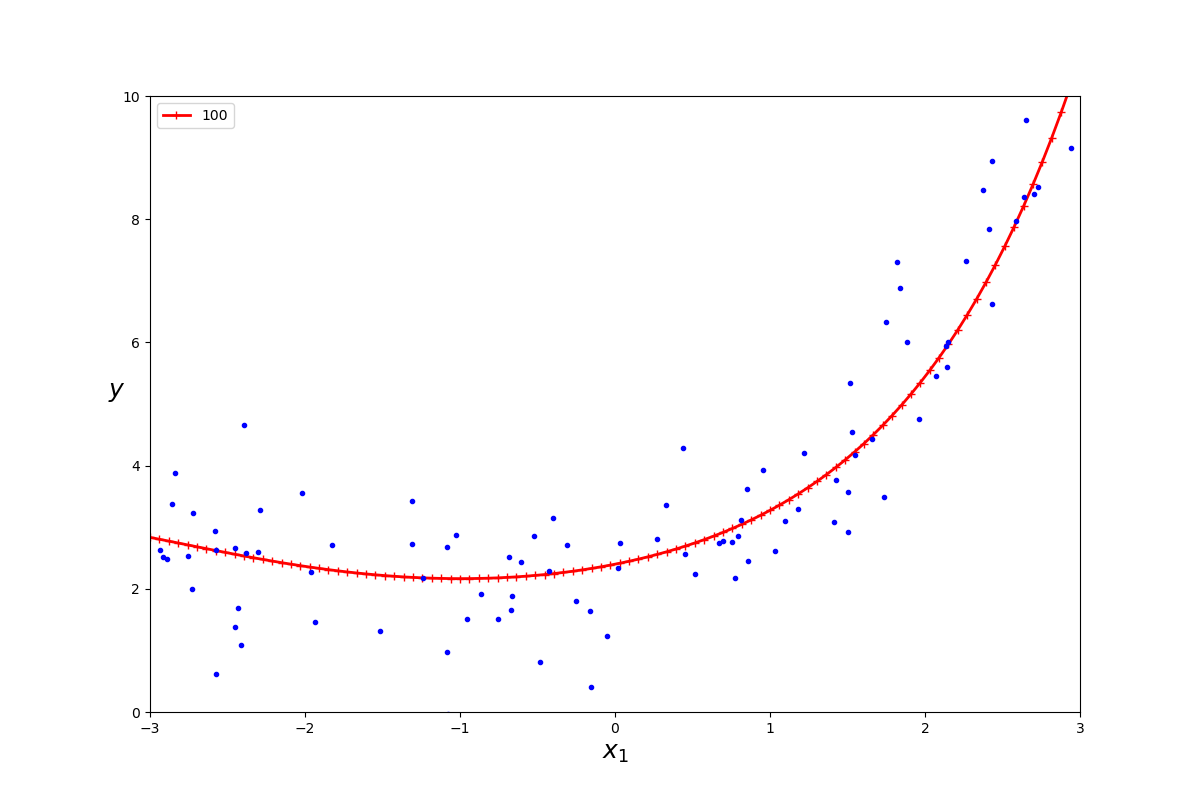

In [61]:
from sklearn.linear_model import ElasticNet

polybig_features = PolynomialFeatures(degree=100, include_bias=False)

std_scaler = StandardScaler()

elastic_reg = ElasticNet(alpha=0.2)

polynomial_regression = Pipeline([
    ("poly_features", polybig_features),
    ("std_scaler", std_scaler),
    ("elastic_reg", elastic_reg),
])

polynomial_regression.fit(X, y)
y_newbig = polynomial_regression.predict(X_new)

plt.figure()
plt.plot(X_new, y_newbig, style, label=str(100), linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3,3,0,10])
plt.show()

In [63]:
elastic_reg.coef_

array([ 0.88747705,  0.84474684,  0.56955485,  0.38772423,  0.28506714,
        0.04752601,  0.02015295,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.  